In [95]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append('../')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from src.data_loader import get_nrel_data

# Change "csv" to "api" if you want to use the NLR API
df = get_nrel_data(source="csv")

print("Raw columns from the API:")
print(df.columns.tolist())

Loading local dataset from ../data/phoenix_2024.csv...
Raw columns from the API:
['GHI', 'DNI', 'DHI', 'Temperature', 'Wind Speed', 'Solar Zenith Angle']


In [97]:
from src.preprocessing import Z_Standardization
import numpy as np

X_scaled, y, mu, sigma = Z_Standardization(df)

# Tells you the dimension of the matrix
print(f"Shape of X_scaled (Features): {X_scaled.shape}")

print(f"Shape of y (Target): {y.shape}")

print(f"Mean of the first feature column (should be ~0): {np.mean(X_scaled[:, 0]):.5f}")

print(f"Std Dev of the first feature column (should be 1): {np.std(X_scaled[:, 0]):.5f}")

Shape of X_scaled (Features): (8760, 5)
Shape of y (Target): (8760,)
Mean of the first feature column (should be ~0): -0.00000
Std Dev of the first feature column (should be 1): 1.00000


In [98]:
from src.preprocessing import bias_column

test_size = 168

X_train_raw = X_scaled[:-test_size]
X_test_raw = X_scaled[-test_size:]

y_train = y[:-test_size]
y_test = y[-test_size:]

X_train = bias_column(X_train_raw)
X_test = bias_column(X_test_raw)

print(f"Training Features (X_train) Shape: {X_train.shape}")
print(f"Testing Features (X_test) Shape:   {X_test.shape}")
print(f"Training Target (y_train) Shape:   {y_train.shape}")

Training Features (X_train) Shape: (8592, 6)
Testing Features (X_test) Shape:   (168, 6)
Training Target (y_train) Shape:   (8592,)


Initializing the Custom Linear Regression Engine...
Training the Model on X_train...
Epoch    0 | MSE Loss: 72747.3251
Epoch  100 | MSE Loss: 10903.7952
Epoch  200 | MSE Loss: 10893.3963
Epoch  300 | MSE Loss: 10893.2990
Epoch  400 | MSE Loss: 10893.2981
Generating Predictions for X_test...

--- FINAL OOP GRADES ---
Training MSE (from model memory): 10893.2981
Testing MSE  (on unseen data):    9763.8607



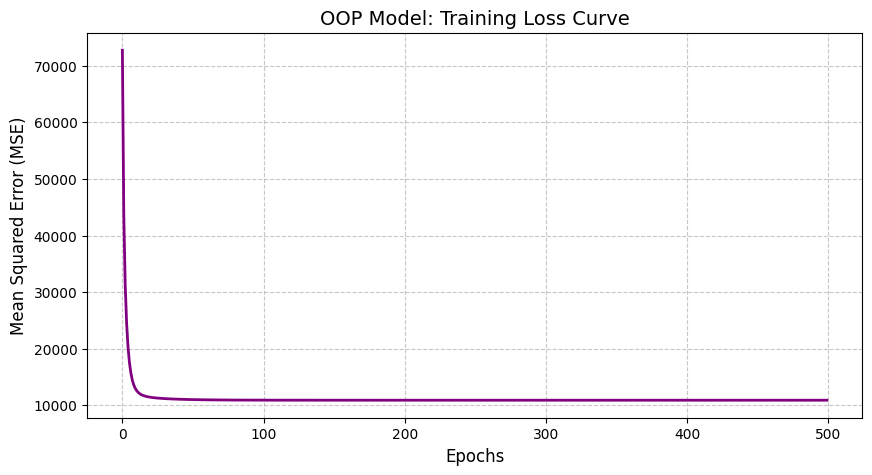

In [99]:
from src.model import CustomLinearRegression
import matplotlib.pyplot as plt
import numpy as np

print("Initializing the Custom Linear Regression Engine...")
model = CustomLinearRegression(learning_rate=0.1, epochs=500)

print("Training the Model on X_train...")
model.fit(X_train, y_train)

print("Generating Predictions for X_test...")
# y_pred_test = np.maximum(0, y_pred_test)
predictions = model.predict(X_test)

test_mse = np.mean(np.square(predictions - y_test))

print(f"\n--- FINAL OOP GRADES ---")
print(f"Training MSE (from model memory): {model.loss_history[-1]:.4f}")
print(f"Testing MSE  (on unseen data):    {test_mse:.4f}\n")

plt.figure(figsize=(10, 5))
plt.plot(model.loss_history, color='purple', linewidth=2)
plt.title("OOP Model: Training Loss Curve", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

FINAL R-SQUARED SCORE: 75.31%



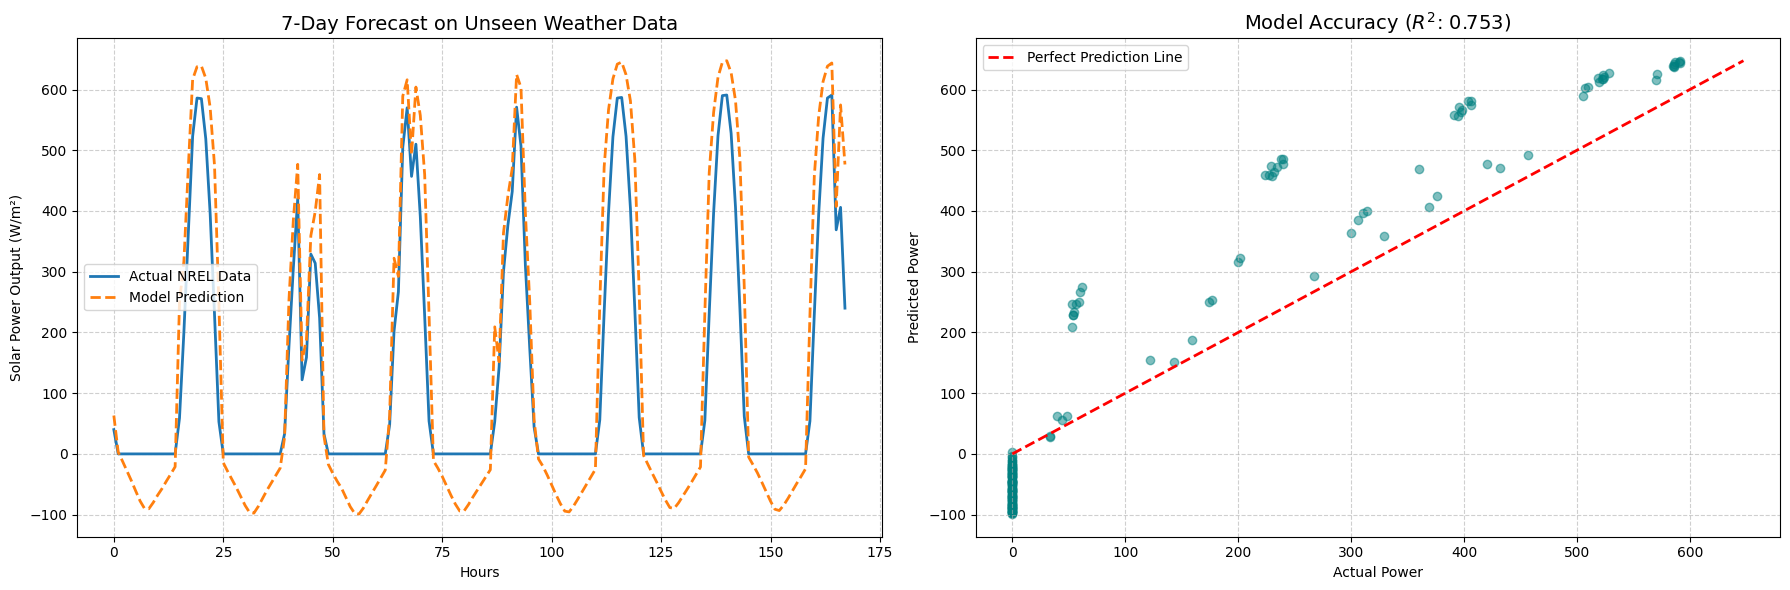

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# Generate final predictions
y_pred_test = model.predict(X_test)

# Calculating the R-Squared Score
ss_total = np.sum(np.square(y_test - np.mean(y_test)))
ss_residual = np.sum(np.square(y_test - y_pred_test))
r2_score = 1 - (ss_residual / ss_total)

print(f"FINAL R-SQUARED SCORE: {r2_score * 100:.2f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# The 7-Day Time Series Overlay 
window = 168 # 7 days
axes[0].plot(y_test[:window], label='Actual NREL Data', color='#1f77b4', linewidth=2)
axes[0].plot(y_pred_test[:window], label='Model Prediction', color='#ff7f0e', linestyle='--', linewidth=2)
axes[0].set_title("7-Day Forecast on Unseen Weather Data", fontsize=14)
axes[0].set_ylabel("Solar Power Output (W/m²)")
axes[0].set_xlabel("Hours")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# The Scatter Plot (Actual vs Predicted) 
axes[1].scatter(y_test, y_pred_test, alpha=0.5, color='teal')

max_val = max(np.max(y_test), np.max(y_pred_test))
axes[1].plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

axes[1].set_title(f"Model Accuracy ($R^2$: {r2_score:.3f})", fontsize=14)
axes[1].set_xlabel("Actual Power")
axes[1].set_ylabel("Predicted Power")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()